<h1> 2. Image Classification of an American Sign Language Dataset</h1> 

In this section, we will perform the data preparation, model creation, and model training steps we observed in the last section using a different dataset: images of hands making letters in American Sign Language.

<h2>2.1 Objectives</h2>
<ul>
<li>Prepare image data for training</li>
<li>Create and compile a simple model for image classification</li>
<li>Train an image classification model and observe the results</li>
<ul>

In [75]:
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

<h2> 2.2 American Sign Language Dataset</h2> 

The American Sign Language (https://www.asl.gs/)  alphabet contains 26 letters. Two of those letters (j and z) require movement, so they are not included in the training dataset.

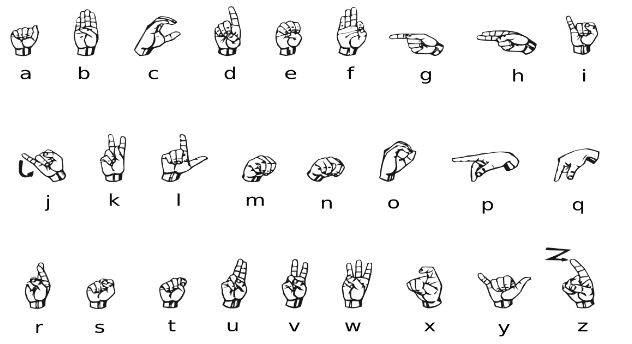

<h3>2.2.1 Kaggle</h3>
This dataset is available from the website Kaggle, which is a fantastic place to find datasets and other deep learning resources. In addition to providing resources like datasets and "kernels" that are like these notebooks, Kaggle hosts competitions that you can take part in, competing with others in training highly accurate models.

If you're looking to practice or see examples of many deep learning projects, Kaggle is a great site to visit.

<h2> 2.3 Loading the Data </h2>
This dataset is not available via TorchVision in the same way that MNIST is, so let's learn how to load custom data. By the end of this section we will have x_train, y_train, x_valid, and y_valid variables.

<h3>2.3.1 Reading in the Data</h3>
The sign language dataset is in CSV (Comma Separated Values) format, the same data structure behind Microsoft Excel and Google Sheets. It is a grid of rows and columns with labels at the top, as seen in the train and valid datasets (they may take a moment to load).

To load and work with the data, we'll be using a library called Pandas, which is a highly performant tool for loading and manipulating data. We'll read the CSV files into a format called a DataFrame.



In [76]:
train_df = pd.read_csv("data/ASL/sign_mnist_train.csv")
valid_df = pd.read_csv("data/ASL/sign_mnist_valid.csv")

<h3>2.3.2 Exploring the Data</h3>
Let's take a look at our data. We can use the head method to print the first few rows of the DataFrame. Each row is an image which has a label column, and also, 784 values (28x28) representing each pixel value in the image, just like with the MNIST dataset. Note that the labels currently are numerical values, not letters of the alphabet:

In [77]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,12,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


<h3>2.3.3 Extracting the Labels</h3>
Let's store our training and validation labels in y_train and y_valid variables. We can use the pop method to remove a column from our DataFrame and assign the removed values to a variable.



In [78]:
y_train = train_df.pop('label')
y_valid = valid_df.pop('label')
print(y_train)
print(y_train.size) # there are 27455 training images

0         3
1         6
2         2
3         2
4        12
         ..
27450    12
27451    22
27452    17
27453    16
27454    22
Name: label, Length: 27455, dtype: int64
27455


<h3>2.3.4 Extracting the Images</h3>
Next, let's store our training and validation images in `x_train` and `x_valid` variables. Here we create those variables:

In [79]:
x_train = train_df.values
x_valid = valid_df.values
x_train

array([[107, 118, 127, ..., 204, 203, 202],
       [155, 157, 156, ..., 103, 135, 149],
       [187, 188, 188, ..., 195, 194, 195],
       ...,
       [174, 174, 174, ..., 202, 200, 200],
       [177, 181, 184, ...,  64,  87,  93],
       [179, 180, 180, ..., 205, 209, 215]], dtype=int64)

<h3>2.3.5 Summarizing the Training and Validation Data</h3>
We now have 27,455 images with 784 pixels each for training...

In [80]:
print('images shape - ', x_train.shape)
print('labels shape - ', y_train.shape)

images shape -  (27455, 784)
labels shape -  (27455,)


<h2>2.4 Visualizing the Data</h2>
To visualize the images, we will again use the matplotlib library. We don't need to worry about the details of this visualization, but if interested, you can learn more about matplotlib at a later time.

Note that we'll have to reshape the data from its current 1D shape of 784 pixels, to a 2D shape of 28x28 pixels to make sense of the image:

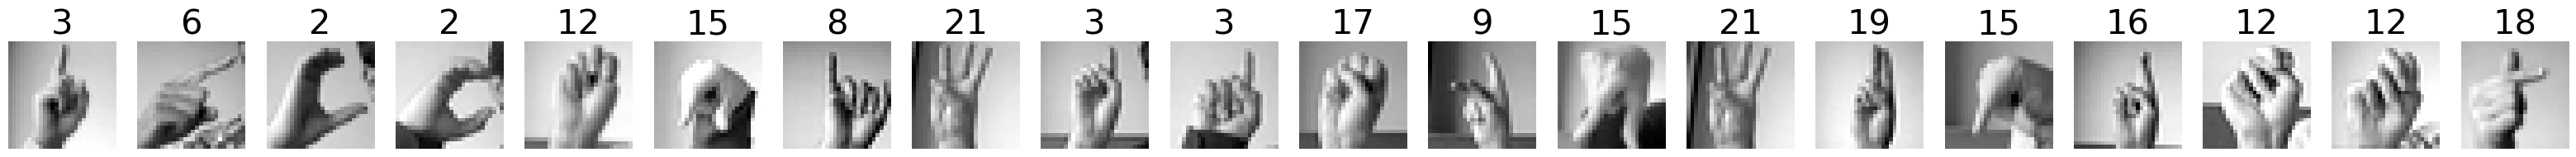

In [81]:
import matplotlib.pyplot as plt
plt.figure(figsize=(40,40))

num_images = 20
for i in range(num_images):
    row = x_train[i]
    label = y_train[i]

    image = row.reshape(28,28)
    plt.subplot(1, num_images, i+1)
    plt.title(label, fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(image, cmap='gray')

<h3>2.4.1 Normalize the Image Data</h3>
Exercise

As we did with the MNIST dataset, we are going to normalize the image data, meaning that their pixel values, instead of being between 0 and 255 as they are currently: (...should be floating point values between 0 and 1. Use the following cell to work. )

In [82]:
x_train.min()
y_train.min()
# SOLUTION
# x_train = x_train / 255 is also correct
x_train = train_df.values / 255
x_valid = valid_df.values / 255

<h3>2.4.2 Custom Datasets</h3>
We can use PyTorch's Dataset tools in order to create our own dataset. __init__ will run once when the class is initialized. __getitem__ returns our images and labels.

Since our dataset is small enough, we can store it on our GPU for faster processing. In the previous lab, we sent our data to the GPU when it was drawn from each batch. Here, we will send it to the GPU in the __init__ function.

In [83]:
class MyDataset(Dataset):
    def __init__(self, x_df, y_df):
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)
    
    # A custom PyTorch dataset works just like a prebuilt one. It should be passed to a DataLoader (https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#preparing-your-data-for-training-with-dataloaders) for model training.
BATCH_SIZE = 32

train_data = MyDataset(x_train, y_train)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
train_N = len(train_loader.dataset)

valid_data = MyDataset(x_valid, y_valid)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE)
valid_N = len(valid_loader.dataset)

# We can verify the DataLoader works as expected with the code below. We'll make the DataLoader iterable, and then call next to draw the first hand from the deck.

train_loader




In [84]:
# Try running the below a few times. The values should change each time.
batch = next(iter(train_loader))
batch

# Notice the batch has two values. The first is our x, and the second is our y. The first dimension of each should have 32 values, which is the batch_size.
print(batch[0].shape)
print(batch[1].shape)

torch.Size([32, 784])
torch.Size([32])


<h2>2.5 Build the Model</h2>
We've created our DataLoaders, now it's time to build our models.
We are going to build a sequential model. Just like last time, build a model that:
<ul>
<li>Has a flatten layer.</li>
<li>Has a dense input layer. This layer should contain 512 neurons amd use the relu activation function</li>
<li>Has a second dense layer with 512 neurons which uses the relu activation function</li>
<li>Has a dense output layer with neurons equal to the number of classes</li>
We will define a few variables to get started:
</ul>

In [85]:
input_size = 28 * 28
n_classes = 26
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
    nn.Linear(512, 512),  # Hidden
    nn.ReLU(),  # Activation for hidden
    nn.Linear(512, n_classes)  # Output
)
# Send the model to the selected device (CPU or GPU)
model = model.to(device)
# model = torch.compile(model.to(device)) - not supportred on windows 11
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=26, bias=True)
)

Since categorizing these ASL images is similar to categorizing MNIST's handwritten digits, we will use the same loss_function (Categorical CrossEntropy) and optimizer (Adam).

In [86]:
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters())

<h2>2.6 Training the Model</h2>

This time, let's look at our train and validate functions in more detail.

<h3> 2.6.1 The Train Function</h3>

This code is almost the same as in the previous notebook, but we no longer send x and y to our GPU because our DataLoader already does that.

Before looping through the DataLoader, we will set the model to model.train (https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.train) to make sure its parameters can be updated. To make it easier for us to follow training progress, we'll keep track of the total loss and accuracy.

Then, for each batch in our train_loader, we will:
<ul>
<li>Get an output prediction from the model</li>
<li>Set the gradient to zero with the optimizer's zero_grad function</li>
<li>Calculate the loss with our loss_function</li>
<li>Compute the gradient with backward  (https://docs.pytorch.org/docs/stable/generated/torch.Tensor.backward.html)</li>
<li>Update our model parameters with the optimizer's step function.</li>
<li>Update the loss and accuracy totals</li>
</ul>

In [87]:

def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

<h3>2.6.2 The Validate Function</h3>

The model does not learn during validation, so the validate function is simpler than the train function above.

One key difference is we will set the model to evaluation mode with model.evaluate, which will prevent the model from updating any parameters.

In [88]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

<h2>2.6.3 The Training Loop</h2>
Let's bring it all together! Run the cell below to train the data for 20 epochs.

In [89]:
epochs = 20

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 1542.6680 Accuracy: 0.4125
Valid - Loss: 290.0692 Accuracy: 0.5686
Epoch: 1
Train - Loss: 659.2430 Accuracy: 0.7396
Valid - Loss: 222.1368 Accuracy: 0.6776
Epoch: 2
Train - Loss: 326.8187 Accuracy: 0.8745
Valid - Loss: 196.7711 Accuracy: 0.7255
Epoch: 3
Train - Loss: 195.8594 Accuracy: 0.9275
Valid - Loss: 198.0415 Accuracy: 0.7310
Epoch: 4
Train - Loss: 102.9667 Accuracy: 0.9643
Valid - Loss: 222.7695 Accuracy: 0.7522
Epoch: 5
Train - Loss: 84.6691 Accuracy: 0.9701
Valid - Loss: 292.5403 Accuracy: 0.7040
Epoch: 6
Train - Loss: 73.7534 Accuracy: 0.9760
Valid - Loss: 222.8622 Accuracy: 0.7681
Epoch: 7
Train - Loss: 61.6507 Accuracy: 0.9784
Valid - Loss: 230.7360 Accuracy: 0.7941
Epoch: 8
Train - Loss: 51.9934 Accuracy: 0.9820
Valid - Loss: 279.9974 Accuracy: 0.7301
Epoch: 9
Train - Loss: 9.2200 Accuracy: 0.9979
Valid - Loss: 243.9904 Accuracy: 0.7936
Epoch: 10
Train - Loss: 69.9383 Accuracy: 0.9734
Valid - Loss: 218.4110 Accuracy: 0.8006
Epoch: 11
Train - Loss: 1.

<h3>2.6.4 Discussion: What happened?</h3>
We can see that the training accuracy got to a fairly high level, but the validation accuracy was not as high. What happened here?

Think about it for a bit ...

This is an example of the model learning to categorize the training data, but performing poorly against new data that it has not been trained on. Essentially, it is memorizing the dataset, but not gaining a robust and general understanding of the problem. This is a common issue called overfitting. We will discuss overfitting in the next two lectures, as well as some ways to address it.

<h2>2.7 Summary</h2>
In this section you built your own neural network to perform image classification that is quite accurate. Congrats!

At this point we should be getting somewhat familiar with the process of loading data (including labels), preparing it, creating a model, and then training the model with prepared data.

<h3>2.7.2 Next</h3>
Now that you have built some very basic, somewhat effective models, we will begin to learn about more sophisticated models, including Convolutional Neural Networks.